In [1755]:
from src.utils import *
from math import sqrt
from scipy.stats import norm
from scipy.stats import binom
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math

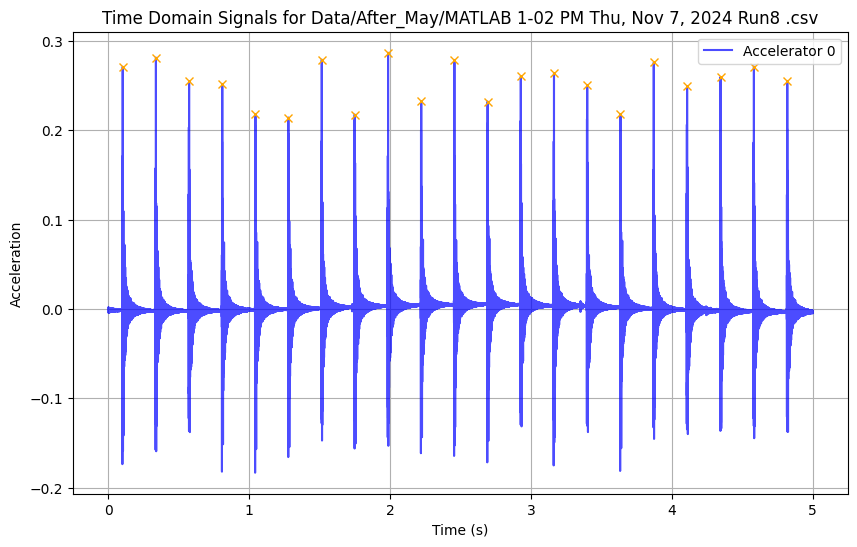

[0.1035 0.3391 0.5746 0.81   1.0454 1.2791 1.516  1.7496 1.9866 2.222
 2.4574 2.693  2.9286 3.1641 3.3999 3.6359 3.8722 4.1088 4.3458 4.5828
 4.8197]


In [1756]:
# Single Rhythmic
file = 'Data/After_May/MATLAB 1-02 PM Thu, Nov 7, 2024 Run8 .csv' # Example 1, sd=0.02
# file = 'Data/After_May/MATLAB 1-21 PM Thu, Nov 7, 2024 Run10 .csv'
# file ='Data/After_May/MATLAB 3-55 PM Thu, Sep 5, 2024 Run0 .csv'
# file = 'Data/After_May/MATLAB 1-12 PM Thu, Nov 7, 2024 Run9 .csv'

# file = 'Data/After_May/MATLAB 1-00 PM Fri, Jun 28, 2024 Run8 .csv'
# file = 'Data/After_May/MATLAB 1-51 PM Tue, Oct 29, 2024 Run13 .csv'
# file = 'Data/After_May/MATLAB 2-45 PM Thu, Oct 24, 2024 Run10 .csv'
# file = 'Data/After_May/MATLAB 1-25 PM Thu, Nov 7, 2024 Run11 .csv'
# file = 'Data/After_May/MATLAB 2-21 PM Mon, Oct 28, 2024 Run4 .csv'
# file = 'Data/After_May/MATLAB 2-47 PM Mon, Oct 28, 2024 Run10 .csv'

# file = 'Data/After_May/MATLAB 1-36 PM Thu, Nov 7, 2024 Run14 .csv'

# file = 'Data/After_May/MATLAB 1-38 PM Thu, Nov 7, 2024 Run15 .csv'
# file = 'Data/After_May/MATLAB 2-23 PM Thu, Oct 31, 2024 Run10 .csv'
# file = 'Data/After_May/MATLAB 2-26 PM Thu, Oct 31, 2024 Run11 .csv'
# file = 'Data/After_May/MATLAB 1-31 PM Tue, Oct 29, 2024 Run7 .csv'
# file = 'Data/After_May/MATLAB 1-53 PM Tue, Oct 29, 2024 Run14 .csv' # Example 3, sd=0.01
# file = 'Data/After_May/MATLAB 2-54 PM Fri, Sep 13, 2024 Run5 .csv'
# file = 'Data/After_May/MATLAB 3-18 PM Tue, Oct 15, 2024 Run9 .csv'
# file = 'Data/After_May/MATLAB 12-54 PM Fri, Jun 28, 2024 Run7 .csv'
# file = 'Data/After_May/MATLAB 3-00 PM Tue, Oct 15, 2024 Run5 .csv' # amplitude
# file = 'Data/After_May/MATLAB 2-15 PM Thu, Oct 31, 2024 Run8 .csv'
# file = 'Data/After_May/MATLAB 2-28 PM Thu, Oct 31, 2024 Run12 .csv'
# file = 'Data/After_May/MATLAB 2-36 PM Fri, Jun 14, 2024 Run14 .csv'
# file = 'Data/After_May/MATLAB 2-47 PM Mon, Oct 28, 2024 Run10 .csv'
# file = 'Data/After_May/MATLAB 3-06 PM Wed, Sep 18, 2024 Run7 .csv' # Example 2, sd=0.02
# file = 'Data/After_May/MATLAB 4-00 PM Mon, Aug 26, 2024 Run5 .csv'

# Double Rhythmic
# file = 'Data/After_May/MATLAB 3-15 PM Thu, Oct 24, 2024 Run15.csv'

# file = 'Data/After_May/MATLAB 2-24 PM Tue, Jun 11, 2024 Run2 .csv'

# Synthetic Data
# file = 'Data/synthetic_data/Synthetic_Dual_Rhythm_1Hz_2Hz.csv'
# file = 'Data/synthetic_data/Synthetic_Irregular_Dual_Rhythm.csv'
# file = 'Data/synthetic_data/Synthetic_Triple_Rhythm_Complex.csv'

acceleration0 = get_file(file)
x, y = get_peaks(acceleration0)

plot_file(file)

print(x)

In [1757]:
# print(np.std(y))
# print(np.mean(y) / 9)

In [1758]:
# x = np.append(x, [0.4926, 1.4703, 2.4728, 6.5517, 7.5904, 14.6235, 15.5775, 16.5513])
# x.sort()
# y = list(acceleration0[x])
# x

In [1759]:
# tall_x = []
# tall_y = []
# short_x = []
# short_y = []
# for peak, height in zip(x, y):
#     if height > 0.8:
#         tall_x.append(float(peak))
#         tall_y.append(float(height))
#     else:
#         short_x.append(float(peak))
#         short_y.append(float(height))
# tall_d = []
# for i in range(len(tall_x) - 1):
#     tall_d.append(float(round(tall_x[i+1] - tall_x[i], 4)))
# short_d = []
# for i in range(len(short_x) - 1):
#     short_d.append(float(round(short_x[i+1] - short_x[i], 4)))
# print(np.std(tall_d), np.std(tall_y))
# print(np.std(short_d), np.std(short_y))

In [1760]:
# d_even = []
# prev = x[0]
# for i in range(2, len(x), 2):
#     d_even.append(float(round(x[i] - prev, 4)))
#     prev = x[i]
# print(np.std(d_even))
#
# d_odd = []
# prev = x[1]
# for i in range(3, len(x), 2):
#     d_odd.append(float(round(x[i] - prev, 4)))
#     prev = x[i]
# print(np.std(d_odd))

In [1761]:
run_length = len(acceleration0) / 10000
run_length

5.0

In [1762]:
#predicted_sd = 0.0017 + 0.0038*(median_peak_amplitude) #(99% one-sided)

def get_x_sd():
    return 0.03
    # median_peak_amplitude = statistics.median(y)
    # return float(0.0017 + 0.0038*median_peak_amplitude)

def get_y_sd():
    return 0.04

In [1763]:
def calculate_x_margin(x_sd, confidence):
    z = norm.ppf(confidence)  # one-sided
    margin = z * x_sd
    return margin


def calculate_y_margin(y_sd, confidence):
    z = norm.ppf(confidence)  # one-sided
    margin = z * y_sd
    return margin


def calculate_p_null(margin, num_peaks, run_length):
    window_fraction = (2 * margin) / run_length
    p_null = 1 - (1 - window_fraction) ** num_peaks
    return min(p_null, 1.0)


class Candidates:
    def __init__(self, x, y, run_length, confidence=0.99, verbose=False):
        self.candidate_lst = []
        self.x_sd = get_x_sd()
        self.y_sd = get_y_sd()
        self.x = x
        self.y = y
        self.run_length = run_length
        self.x_margin = calculate_x_margin(self.x_sd, confidence)
        self.y_margin = calculate_y_margin(self.y_sd, confidence)
        self.cur_id = 0
        self.num_peaks = len(x)
        self.p_null = calculate_p_null(self.x_margin, self.num_peaks, self.run_length)
        self.alpha = 0.05
        self.used_peaks = set()
        self.verbose = verbose

    def __repr__(self):
        return "\n".join(repr(c) for c in self.candidate_lst)

    def add_candidate(self, candidate):
        self.candidate_lst.append(candidate)
        self.cur_id += 1

    def generate_candidates(self, verbose=None):
        verbose = self.verbose if verbose is None else verbose
        for i in range(self.get_max_start_index()):
            for j in range(i + 1, self.num_peaks):
                d = round(self.x[j] - self.x[i], 4)
                if self.x[j] + self.get_min_hits()*d / 2 > self.run_length + self.x_margin:
                    break
                if d < 2*self.x_margin or self.y[i] - self.y[j] > 2*self.y_margin:
                    continue
                anchor = self.x[i]
                candidate = Candidate(self.cur_id, d, anchor)
                self.add_candidate(candidate)
                if verbose:
                    print(f"Generated candidate {candidate.id}: d={d}, anchor={anchor}")
        if verbose:
            print(f"Total candidates generated: {len(self.candidate_lst)}")

    def add_hit_data(self, verbose=None):
        verbose = self.verbose if verbose is None else verbose
        for candidate in self.candidate_lst:
            candidate.count_hits(self.x, self.y, self.x_margin, self.y_margin)
            if verbose:
                print(f"Candidate {candidate.id}: d={candidate.d}, hits={candidate.hits}, tries={candidate.tries}, indices={candidate.hit_indices}")

    def prune_insufficient_hits(self, verbose=None):
        verbose = self.verbose if verbose is None else verbose
        original_count = len(self.candidate_lst)
        self.candidate_lst = [
            candidate for candidate in self.candidate_lst
            if candidate.hits >= 3
            and candidate.binomial_test(
                self.p_null,
                alpha=self.alpha / self.get_num_regimes() # Bonferroni Adjustment
            )
        ]
        if verbose:
            print(f"Pruned {original_count - len(self.candidate_lst)} candidates by significance")
            for candidate in self.candidate_lst:
                print(f"Candidate {candidate.id}: d={candidate.d}, hits={candidate.hits}, tries={candidate.tries}, indices={candidate.hit_indices}")

    def group_candidates_by_similarity(self, threshold=0.75, verbose=None):
        verbose = self.verbose if verbose is None else verbose
        candidates = self.candidate_lst
        n = len(candidates)
        ids = [c.id for c in candidates]
        sim_matrix = np.zeros((n, n))

        # Compute Szymkiewicz–Simpson overlap coefficient
        for i in range(n):
            for j in range(n):
                if i == j:
                    sim_matrix[i][j] = 1.0
                    continue
                s1 = set(candidates[i].hit_indices or [])
                s2 = set(candidates[j].hit_indices or [])
                if not s1 or not s2:
                    sim = 0.0
                else:
                    sim = len(s1 & s2) / min(len(s1), len(s2))
                sim_matrix[i][j] = sim

        if verbose:
            df = pd.DataFrame(sim_matrix, index=ids, columns=ids)
            print("Overlap Coefficient Matrix:")
            print(df.round(2))

        # Build similarity graph
        G = nx.Graph()
        G.add_nodes_from(ids)
        for i in range(n):
            for j in range(i + 1, n):
                if sim_matrix[i][j] >= threshold:
                    G.add_edge(ids[i], ids[j])

        if verbose:
            pos = nx.spring_layout(G, seed=452)
            fig, ax = plt.subplots(figsize=(8, 6))
            nx.draw(
                G, pos, ax=ax,
                with_labels=True,
                node_color='lightblue',
                edge_color='gray',
                node_size=800,
                font_size=10
            )
            ax.set_title(f"Candidate Similarity Graph (Threshold = {threshold:.2f})")
            plt.tight_layout()
            plt.show()

        # Keep strongest candidate in each group, absorb extra hit indices
        id_to_candidate = {c.id: c for c in candidates}
        dominant_candidates = []

        for group in nx.connected_components(G):
            group_cands = [id_to_candidate[i] for i in group]
            centrality = nx.degree_centrality(G)
            dominant = max(group_cands, key=lambda c: (centrality[c.id], c.hits))

            dominant_hits = set(dominant.hit_indices or [])
            absorbed_hits = set()

            for c in group_cands:
                if c is not dominant:
                    absorbed_hits.update(set(c.hit_indices or []) - dominant_hits)

            dominant.absorbed = sorted(absorbed_hits)
            dominant_candidates.append(dominant)

            if verbose and len(group_cands) > 1:
                group_ids = [c.id for c in group_cands]
                print(f"Merged group {group_ids} into candidate {dominant.id}. Absorbed {len(dominant.absorbed)} extra hit indices.")

        self.candidate_lst = dominant_candidates

        if verbose:
            print(f"Retaining {len(dominant_candidates)} dominant candidate{'s' if len(dominant_candidates) != 1 else ''} from similarity groups.")

    def get_max_start_index(self):
        max_start = int(self.num_peaks / 2)
        return min(max_start, self.num_peaks - 1)

    def get_min_hits(self):
        min_hits = math.ceil(sqrt(self.num_peaks))
        return max(min_hits, 1)

    def remove_outliers(self, verbose=None):
        verbose = self.verbose if verbose is None else verbose
        min_hits = self.get_min_hits()

        original_count = len(self.candidate_lst)
        self.candidate_lst = [
            candidate
            for candidate in self.candidate_lst
            if len(candidate.hit_indices) + len(candidate.absorbed) >= min_hits
        ]

        if verbose:
            removed_count = original_count - len(self.candidate_lst)
            print(f"Removed {removed_count} outlier candidate{'s' if removed_count != 1 else ''} (min_hits = {min_hits})")


    def count_unused_peaks(self): # must be called after detect_regimes()
        used_peaks = set()
        for candidate in self.candidate_lst:
            for peak in candidate.hit_indices:
                used_peaks.add(peak)
            for peak in candidate.absorbed:
                used_peaks.add(peak)
        return self.num_peaks - len(used_peaks)

    def get_unused_peak_proportion(self):
        return self.count_unused_peaks() / self.num_peaks

    def get_num_regimes(self):
        return len(self.candidate_lst)

    def detect_regimes(self, verbose=None):
        verbose = self.verbose if verbose is None else verbose

        if verbose:
            print("Step 1: Generating candidates...")
        self.generate_candidates(verbose=verbose)

        if verbose:
            print("\nStep 2: Adding hit data...")
        self.add_hit_data(verbose=verbose)

        if verbose:
            print("\nStep 3: Pruning by binomial test...")
        self.prune_insufficient_hits(verbose=verbose)

        if verbose:
            print("\nStep 4: Grouping by hit similarity (overlap coefficient)...")
        self.group_candidates_by_similarity(verbose=verbose)

        if verbose:
            print("\nStep 5: Remove final outlier candidates with insufficient hits")
        self.remove_outliers(verbose=verbose)

        if verbose:
            print("\nFinal number of remaining candidates:")
        return self.get_num_regimes()


# # For debugging only
# candidates = Candidates(x, y, run_length)
# candidates.detect_regimes(verbose=True)

In [1764]:
class Candidate:
    def __init__(self, id, d, anchor):
        self.id = id
        self.d = d
        self.anchor = anchor
        self.hit_indices = None
        self.hits = None
        self.tries = None
        self.absorbed = []

    def __repr__(self):
        res = f"ID: {self.id}, d: {self.d:.6f}, Anchor: {self.anchor:.6f}"
        if self.hits and self.tries:
            res += f", Hits: {self.hits}, Tries: {self.tries}, Indices: {self.hit_indices}"
        if self.absorbed:
            res += f", Absorbed: {self.absorbed}"
        return res

    def count_hits(self, x, y, x_margin, y_margin):#, confidence=0.99):
        x = np.array(x)
        y = np.array(y)

        # Anchor is a guaranteed hit
        anchor_idx = np.where(x == self.anchor)[0][0]

        hit_indices = [int(anchor_idx)]
        tries = 1
        last_hit = self.anchor

        while True:
            t = last_hit + self.d
            if t > x[-1] + x_margin:
                break

            # Find candidate peaks within x-margin
            x_mask = (x >= t - x_margin) & (x <= t + x_margin)
            candidate_idxs = np.where(x_mask)[0]

            if candidate_idxs.size > 0:
                # Only keep candidates whose y-values are within y_margin of moving average y
                recent_hits_y = y[hit_indices[-3:]]  # last 3 hits
                expected_y = np.mean(recent_hits_y)
                y_diff = np.abs(y[candidate_idxs] - expected_y)
                valid_mask = y_diff <= y_margin
                valid_idxs = candidate_idxs[valid_mask]

                if valid_idxs.size > 0:
                    # Pick closest in x
                    distances = np.abs(x[valid_idxs] - t)
                    hit_idx = int(valid_idxs[np.argmin(distances)])
                    hit_indices.append(hit_idx)
                    last_hit = x[hit_idx]  # snap to actual hit
                else:
                    last_hit = t  # step forward linearly
            else:
                last_hit = t  # step forward linearly

            tries += 1

        self.hit_indices = hit_indices
        self.hits = len(hit_indices)
        self.tries = tries

    def binomial_test(self, p_null, alpha=0.01):
        if not self.hits:
            raise RuntimeError("Must call `count_hits()` before `binomial_test()`")
        if self.hits < 3:
            return False
        p_value = 1 - binom.cdf(self.hits - 2, self.tries - 2, p_null) # skip first 2 guaranteed hits
        return p_value < alpha


# # For debugging only
# candidates = Candidates(x, y, run_length)
# candidates.detect_regimes(verbose=True)

Step 1: Generating candidates...
Generated candidate 0: d=0.2356, anchor=0.1035
Generated candidate 1: d=0.4711, anchor=0.1035
Generated candidate 2: d=0.7065, anchor=0.1035
Generated candidate 3: d=0.9419, anchor=0.1035
Generated candidate 4: d=1.1756, anchor=0.1035
Generated candidate 5: d=1.4125, anchor=0.1035
Generated candidate 6: d=0.2355, anchor=0.3391
Generated candidate 7: d=0.4709, anchor=0.3391
Generated candidate 8: d=0.7063, anchor=0.3391
Generated candidate 9: d=0.94, anchor=0.3391
Generated candidate 10: d=1.1769, anchor=0.3391
Generated candidate 11: d=0.2354, anchor=0.5746
Generated candidate 12: d=0.4708, anchor=0.5746
Generated candidate 13: d=0.7045, anchor=0.5746
Generated candidate 14: d=0.9414, anchor=0.5746
Generated candidate 15: d=1.175, anchor=0.5746
Generated candidate 16: d=0.2354, anchor=0.81
Generated candidate 17: d=0.4691, anchor=0.81
Generated candidate 18: d=0.706, anchor=0.81
Generated candidate 19: d=0.9396, anchor=0.81
Generated candidate 20: d=1.1

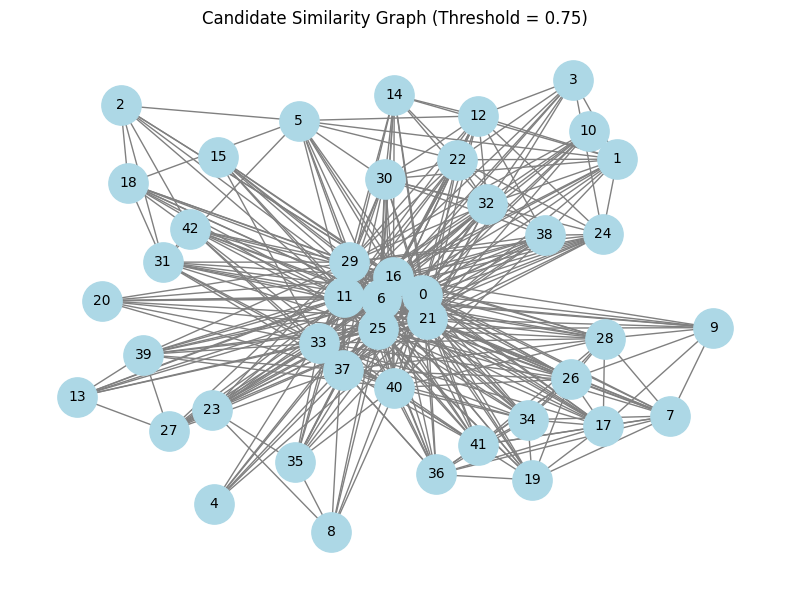

Merged group [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42] into candidate 0. Absorbed 0 extra hit indices.
Retaining 1 dominant candidate from similarity groups.

Step 5: Remove final outlier candidates with insufficient hits
Removed 0 outlier candidates (min_hits = 5)

Final number of remaining candidates:


1

In [1765]:
candidates = Candidates(x, y, run_length)
candidates.detect_regimes(verbose=True)
candidates.get_num_regimes()

In [1766]:
candidates

ID: 0, d: 0.235600, Anchor: 0.103500, Hits: 21, Tries: 21, Indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

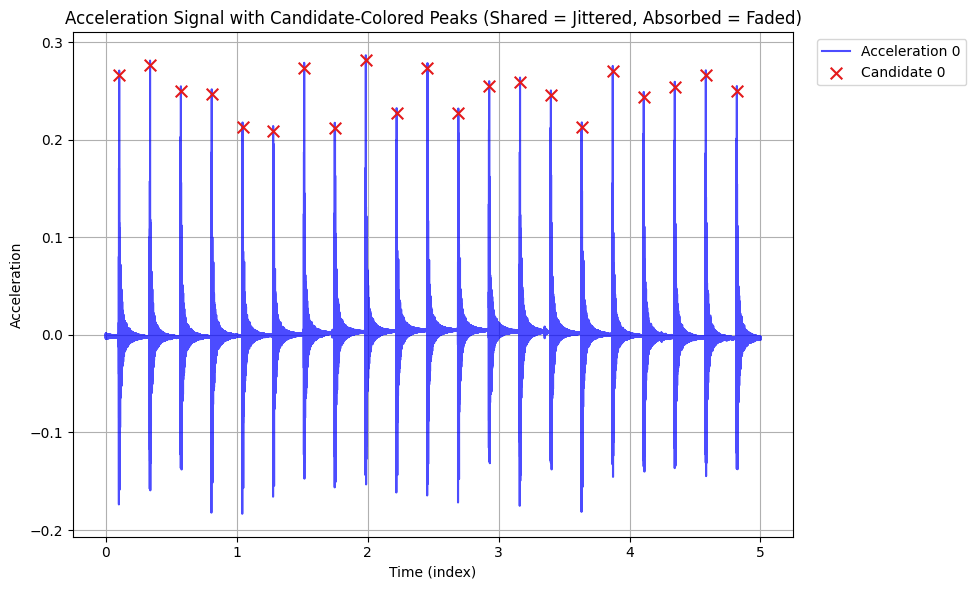

In [1767]:
def plot_candidate_peak_sets(acceleration0, peaks, candidates):
    """
    Plot the acceleration signal with peaks, coloring each candidate's peak set uniquely.
    Shared peaks are plotted with small vertical jitter so all colors are visible.
    Absorbed peaks are plotted in the same color but lighter.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from collections import defaultdict

    peaks = np.array(peaks)
    cmap = plt.colormaps["Set1"]
    plt.figure(figsize=(10, 6))
    plt.plot(acceleration0, label='Acceleration 0', color='blue', alpha=0.7)

    # Map each peak index to all candidate indices using it
    peak_to_candidates = defaultdict(list)
    for i, candidate in enumerate(candidates):
        if candidate.hit_indices:
            for hit in candidate.hit_indices:
                peak_to_candidates[hit].append(i)

    used_peak_indices = set()

    for i, candidate in enumerate(candidates):
        color = cmap(i % cmap.N)

        # Plot main hit_indices with jitter
        if candidate.hit_indices:
            for hit in candidate.hit_indices:
                peak_idx = peaks[hit]
                base_y = acceleration0[peak_idx]
                shared_users = peak_to_candidates[hit]
                jitter = 0.01 * (shared_users.index(i) - len(shared_users) / 2)
                plt.scatter(peak_idx, base_y + jitter,
                            color=color,
                            label=f"Candidate {candidate.id}" if hit == candidate.hit_indices[0] else None,
                            zorder=3, marker="x", s=70)
                used_peak_indices.add(hit)

        # Plot absorbed peaks in lighter color
        if hasattr(candidate, 'absorbed') and candidate.absorbed:
            for hit in candidate.absorbed:
                if hit not in used_peak_indices:
                    peak_idx = peaks[hit]
                    plt.scatter(peak_idx, acceleration0[peak_idx],
                                color=color, alpha=0.3,
                                label=f"Absorbed (Cand {candidate.id})" if hit == candidate.absorbed[0] else None,
                                zorder=2, marker="x", s=60)
                    used_peak_indices.add(hit)

    # Unused peaks
    all_peak_indices = set(range(len(peaks)))
    unused_peak_indices = np.array(sorted(all_peak_indices - used_peak_indices))
    if len(unused_peak_indices) > 0:
        unused_peaks = peaks[unused_peak_indices]
        plt.scatter(unused_peaks, acceleration0[unused_peaks],
                    color='gray', alpha=0.5, label='Unused Peaks',
                    zorder=1, marker="x", s=40)

    plt.title("Acceleration Signal with Candidate-Colored Peaks (Shared = Jittered, Absorbed = Faded)")
    plt.xlabel("Time (index)")
    plt.ylabel("Acceleration")
    plt.legend(loc='upper right', bbox_to_anchor=(1.25, 1.0))
    plt.grid(True)
    plt.tight_layout()
    plt.show()


plot_candidate_peak_sets(acceleration0, x, candidates.candidate_lst)

In [1768]:
candidates.get_unused_peak_proportion()

0.0

In [1769]:
len(candidates.candidate_lst[0].hit_indices)
candidates

ID: 0, d: 0.235600, Anchor: 0.103500, Hits: 21, Tries: 21, Indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]